# DECISION TREE

## DECISION TREE:
  *  A Decision Tree is a supervised learning algorithm used for both classification and regression tasks. It represents decisions in a tree-like structure with a root node (entire dataset), branches (decision paths), internal nodes (decision points), and leaf nodes (final outcomes) .

  *  It works by recursively splitting the dataset based on feature values using criteria like Gini Impurity or Entropy/Information Gain to create the most homogeneous subsets possible .

### Types of Decision Trees

* Classification Trees – Predict categorical outcomes (e.g., spam vs. not spam).

* Regression Trees – Predict continuous values (e.g., house prices) .

### How It Works

> * Start at the root node with the full dataset.

> * Select the best feature to split using a criterion (e.g., Gini, Entropy).

> * Branch out based on feature values.

> * Repeat splitting until stopping conditions are met.

> * Assign outcomes at leaf nodes .


## Example in Python (Classification Tree)

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.datasets import load_iris

## Load dataset
iris = load_iris()
X, y = iris.data, iris.target

## Train Decision Tree
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
clf.fit(X, y)

## Display tree rules
print(export_text(clf, feature_names=iris.feature_names))
Copy
This code trains a Gini-based decision tree on the Iris dataset and prints the decision rules.

## Advantages

> * Easy to interpret and visualize.

> * Works with categorical and numerical data without scaling.

> * Handles non-linear relationships well .

## Limitations

> * Overfitting if too deep (mitigated by pruning).

> * High variance – small data changes can alter the tree.

> * Can be biased toward features with many categories .

## Applications

> * Banking – Loan approval prediction.

> * Healthcare – Disease diagnosis.

> * Marketing – Customer churn prediction.

> * Finance – Fraud detection .



## PROBLEM STATEMENT :

## 📌 Problem Statement

    * Forests are vital ecosystems that require careful monitoring and management. The *Covtype* dataset provides cartographic variables such as elevation, slope, soil type, and climate features, which can be used to classify different forest cover types. The challenge is to build a machine learning model that can accurately predict the forest cover type (seven possible classes) based on these environmental attributes.  

    * This is a **multi-class classification problem**, where the objective is to develop a predictive model using a **Decision Tree algorithm**. The model should not only achieve high accuracy but also provide interpretable insights into which features (e.g., elevation, soil type, wilderness area) most influence forest cover classification. Such predictions can support ecological research, land management, and conservation planning.

## DATA COLLECTION:

## 📊 Data Collection (Forest Cover Classification):

1. **Source of Data**  
    - The dataset from kaggle websites. Link: https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset
    - The dataset used in this project is the **Forest Cover Type dataset (Covtype)**, originally from the **UCI Machine Learning Repository**.  
    - It contains cartographic variables derived from US Geological Survey data. 


2. **Dataset Description**  
   - **Instances:** ~581,000 records  
   - **Features:** 54 attributes (both continuous and categorical)  
   - **Target Variable:** `Cover_Type` (integer values 1–7, representing seven forest cover types)  
   - **Feature Categories:**  
     - Elevation, Aspect, Slope  
     - Horizontal & Vertical distances to hydrology  
     - Hillshade indices (morning, noon, afternoon)  
     - Soil type (categorical, 40 binary indicators)  
     - Wilderness area (categorical, 4 binary indicators)  

3. **Nature of Data**  
   - Structured **tabular dataset** (rows = forest plots, columns = features).  
   - Each row represents one forest plot with environmental attributes and its corresponding forest cover type.  

4. **Purpose of Collection**  
   - To classify forest cover types based on environmental and soil features.  
   - Supports ecological monitoring, land management, and predictive modeling.  

5. **Storage & Access**  
   - Stored as a `.csv` file (`covtype.csv`).  
   - Loaded into Python using `pandas.read_csv("covtype.csv")`.  
   - Preprocessed before feeding into the Decision Tree algorithm.  


## DOMAIN ANALYSIS

## 🌐 Domain Analysis (Forest Cover Classification)

### 1. **Context**
Forests are complex ecosystems influenced by terrain, soil, and climate. Predicting forest cover type is crucial for ecological monitoring, wildfire prevention, and sustainable land management. The Covtype dataset provides cartographic variables (elevation, slope, soil type, wilderness area, hydrology distances, hillshade indices) that can be used to classify forest cover types into seven categories.

---

### 2. **Challenges**
- **High Dimensionality:** 54 features, including categorical indicators for soil and wilderness areas.  
- **Class Imbalance:** Some forest types are more frequent than others, leading to skewed predictions.  
- **Non-linear Relationships:** Environmental variables interact in complex ways that simple linear models may fail to capture.  
- **Overfitting Risk:** Decision Trees can easily overfit if not properly tuned (e.g., depth control).  

---

### 3. **Analytical Needs**
- Feature engineering to handle categorical variables effectively.  
- Dimensionality reduction or feature importance analysis to identify key predictors.  
- Robust evaluation metrics beyond accuracy (precision, recall, F1-score).  
- Interpretability to understand which environmental factors drive classification.  

---

### 4. **Role of Decision Tree**
- Handles both numerical and categorical features without extensive preprocessing.  
- Provides interpretable rules for forest cover classification.  
- Captures non-linear interactions between terrain and soil variables.  
- Serves as a baseline model before moving to ensemble methods (Random Forest, Gradient Boosting).  

---

### 5. **Business & Research Impact**
- **Ecological Monitoring:** Helps researchers identify forest types based on terrain and soil data.  
- **Land Management:** Supports government agencies in planning conservation strategies.  
- **Wildfire Prevention:** Certain forest types are more prone to fire; classification aids risk assessment.  
- **Data-Driven Insights:** Elevation and soil type often emerge as dominant predictors, guiding resource allocation.  

## IMPORTING LIBRARIES

In [1]:
## 📦 Import Libraries

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - preprocessing, model, evaluation
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Utility
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### 🔑 Explanation of Each Library
- **pandas** → For loading and handling the dataset (`covtype.csv`).  
- **numpy** → For numerical operations and array manipulations.  
- **matplotlib & seaborn** → For data visualization (feature distributions, correlations, confusion matrix plots).  
- **sklearn.model_selection** → Provides `train_test_split` to divide data into training and testing sets.  
- **sklearn.tree.DecisionTreeClassifier** → Core algorithm for building the Decision Tree model. 
- **sklearn.metrics** → Tools to evaluate model performance (accuracy, precision, recall, F1-score, confusion matrix).

## LOADING DATASET

In [2]:
import pandas as pd

# Step 1: Load dataset
df = pd.read_csv("covtype.csv")

# Step 2: Inspect dataset
print("Dataset Shape:\n", df.shape)   # Rows and columns
print(df.head()) # First 5 records
print(df.tail()) # last 5 records
print(df.info()) 

Dataset Shape:
 (581012, 55)
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2     

### 📊 Explanation
- `df.shape` → Displays the number of rows and columns (expected ~581,000 rows and 55 columns).  
- `df.head()` → Shows the first few records for a quick preview.
- `df.tail()` → Shows the last few records for a quick preview. 
- `df.info()` → Provides details about column data types and missing values.  

## BASIC CHECKS

In [3]:
# Dataset shape
print("Shape of dataset:", df.shape)

# Column info
print("\nColumn Information:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate records
print("\nDuplicate Records:", df.duplicated().sum())

# Target variable distribution
print("\nCover_Type Distribution:")
print(df['Cover_Type'].value_counts())

Shape of dataset: (581012, 55)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  

### 📌 Explanation
- **Shape:** Confirms ~581,000 rows and 55 columns.  
- **Info:** Ensures all features are properly typed (int/float).  
- **Missing Values:** Covtype dataset typically has **no missing values**, but this check validates it.  
- **Duplicates:** Rare, but checking ensures data integrity.  
- **Distribution:** Reveals class imbalance (some forest types are more frequent than others).  

## Exploratory Data Analysis (EDA)

### 1. **Statistical Summary**
- Use `.describe()` to get mean, median, min, max, and standard deviation of continuous features.  
- Helps identify outliers and ranges of variables like `Elevation`, `Slope`, and `Aspect`.


In [8]:
df.describe

<bound method NDFrame.describe of         Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0            2596      51      3                               258   
1            2590      56      2                               212   
2            2804     139      9                               268   
3            2785     155     18                               242   
4            2595      45      2                               153   
...           ...     ...    ...                               ...   
581007       2396     153     20                                85   
581008       2391     152     19                                67   
581009       2386     159     17                                60   
581010       2384     170     15                                60   
581011       2383     165     13                                60   

        Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                                    0            

### 2. **Target Variable Distribution**
- Check how balanced the `Cover_Type` classes are.  
- Some forest types dominate, while others are underrepresented → may affect model performance.


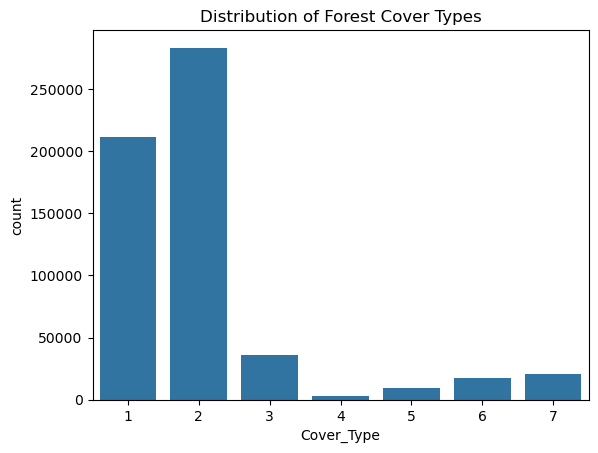

In [9]:
sns.countplot(x='Cover_Type', data=df)
plt.title("Distribution of Forest Cover Types")
plt.show();

### 3. **Feature Distributions**
- Plot histograms for continuous variables (e.g., Elevation, Slope).  
- Helps visualize spread and skewness.

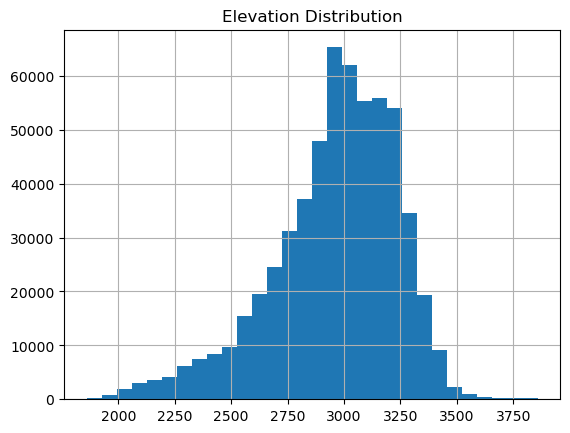

In [11]:
df['Elevation'].hist(bins=30)
plt.title("Elevation Distribution")
plt.show();

### 4. **Correlation Analysis**
- Use a heatmap to check correlations among continuous features.  
- Example: Elevation often correlates with hydrology distances.

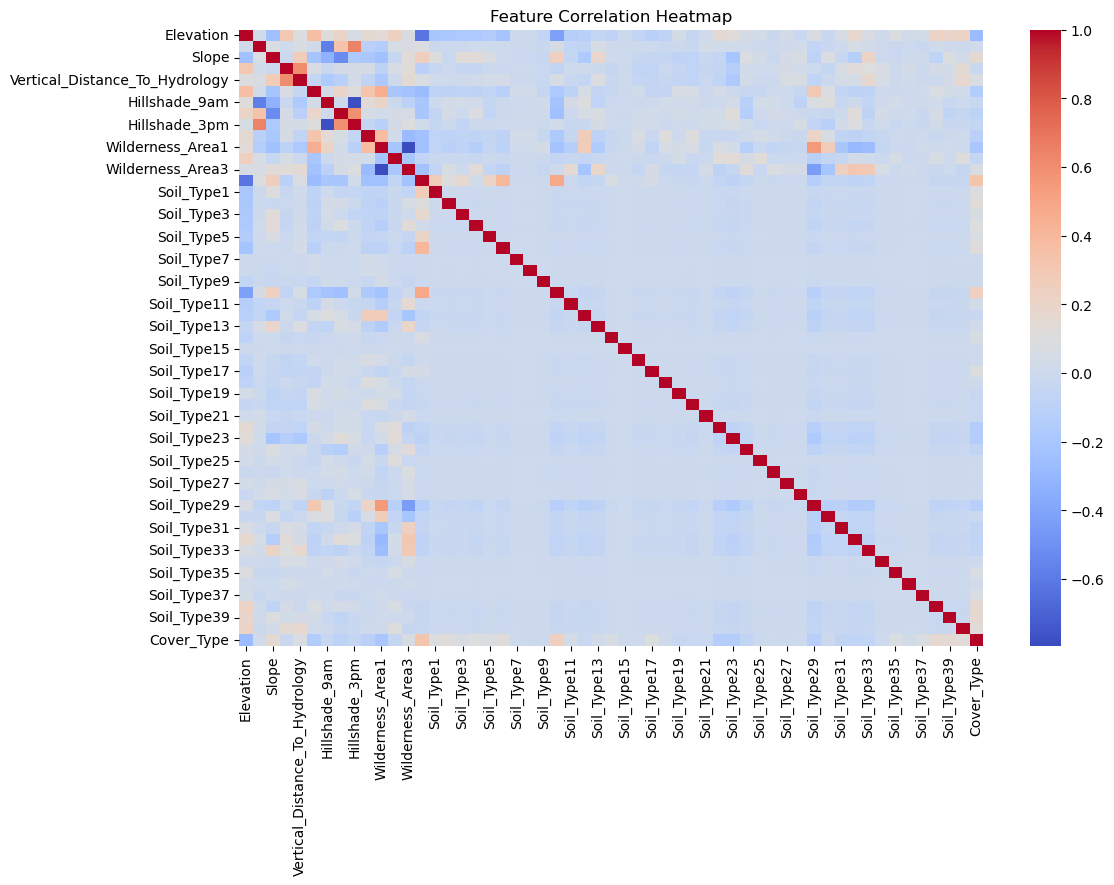

In [12]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show();

### 5. **Categorical Feature Analysis**
- Wilderness Area and Soil Type are one-hot encoded (binary indicators).  
- Check frequency of each category to understand diversity.

In [13]:
print(df.filter(like='Wilderness_Area').sum())
print(df.filter(like='Soil_Type').sum())

Wilderness_Area1    260796
Wilderness_Area2     29884
Wilderness_Area3    253364
Wilderness_Area4     36968
dtype: int64
Soil_Type1       3031
Soil_Type2       7525
Soil_Type3       4823
Soil_Type4      12396
Soil_Type5       1597
Soil_Type6       6575
Soil_Type7        105
Soil_Type8        179
Soil_Type9       1147
Soil_Type10     32634
Soil_Type11     12410
Soil_Type12     29971
Soil_Type13     17431
Soil_Type14       599
Soil_Type15         3
Soil_Type16      2845
Soil_Type17      3422
Soil_Type18      1899
Soil_Type19      4021
Soil_Type20      9259
Soil_Type21       838
Soil_Type22     33373
Soil_Type23     57752
Soil_Type24     21278
Soil_Type25       474
Soil_Type26      2589
Soil_Type27      1086
Soil_Type28       946
Soil_Type29    115247
Soil_Type30     30170
Soil_Type31     25666
Soil_Type32     52519
Soil_Type33     45154
Soil_Type34      1611
Soil_Type35      1891
Soil_Type36       119
Soil_Type37       298
Soil_Type38     15573
Soil_Type39     13806
Soil_Type40      8750

### 6. **Class Imbalance Check**
- Some cover types (like Spruce/Fir) are more frequent than others.  
- May require resampling or weighted metrics during evaluation.

## 📊 Exploratory Data Analysis (EDA):
### 📌 Insights from EDA
- **Elevation** is a dominant feature, showing clear separation between forest types.  
- **Soil Type** and **Wilderness Area** strongly influence classification.  
- Dataset is **imbalanced**, requiring careful evaluation beyond accuracy.  
- No missing values, but high dimensionality (54 features) → feature importance analysis is useful.

## Feature Selection

## 🎯 Feature Selection

> *  Feature selection is a critical step in machine learning workflows.
> *  It reduces dimensionality, improves model performance, and highlights the most influential variables for classification.
> *  Since the Covtype dataset has **54 features**,
> *  selecting the most relevant ones ensures the Decision Tree model avoids overfitting and remains interpretable.


### 1. **Correlation Analysis**
- Identify features strongly correlated with the target (`Cover_Type`).  
- Continuous variables like **Elevation, Slope, Hydrology distances, Hillshade indices** often show meaningful relationships.  

In [14]:
corr = df.corr()
print(corr['Cover_Type'].sort_values(ascending=False))

Cover_Type                            1.000000
Wilderness_Area4                      0.323200
Soil_Type10                           0.243876
Soil_Type38                           0.160170
Soil_Type39                           0.155668
Slope                                 0.148285
Soil_Type40                           0.128351
Soil_Type2                            0.118135
Soil_Type6                            0.112958
Soil_Type4                            0.099672
Soil_Type1                            0.090828
Soil_Type17                           0.090582
Vertical_Distance_To_Hydrology        0.081664
Soil_Type35                           0.080315
Soil_Type37                           0.080271
Soil_Type5                            0.077890
Soil_Type3                            0.068064
Wilderness_Area3                      0.066846
Soil_Type14                           0.065562
Soil_Type11                           0.035379
Soil_Type36                           0.025397
Soil_Type13  

### 2. **Univariate Feature Selection (SelectKBest)**
- Use statistical tests (`chi2` for categorical, `f_classif` for continuous) to rank features.  
- Select top features that contribute most to classification.

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['Elevation', 'Horizontal_Distance_To_Roadways', 'Wilderness_Area1',
       'Wilderness_Area4', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4',
       'Soil_Type10', 'Soil_Type38', 'Soil_Type39'],
      dtype='object')


### 3. **Feature Importance via Decision Tree**
- Train a preliminary Decision Tree and extract feature importance scores.  
- Helps identify dominant predictors like **Elevation, Soil Type, Wilderness Area**.

In [16]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

importances = pd.Series(clf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10))

Elevation                             0.335419
Horizontal_Distance_To_Roadways       0.152071
Horizontal_Distance_To_Fire_Points    0.143306
Horizontal_Distance_To_Hydrology      0.062241
Vertical_Distance_To_Hydrology        0.043673
Hillshade_Noon                        0.033319
Hillshade_9am                         0.029899
Aspect                                0.026012
Hillshade_3pm                         0.022150
Slope                                 0.017157
dtype: float64


### 3. **Feature Importance via Decision Tree**
- Train a preliminary Decision Tree and extract feature importance scores.  
- Helps identify dominant predictors like **Elevation, Soil Type, Wilderness Area**.

In [17]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

importances = pd.Series(clf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10))

Elevation                             0.335419
Horizontal_Distance_To_Roadways       0.152071
Horizontal_Distance_To_Fire_Points    0.143306
Horizontal_Distance_To_Hydrology      0.062241
Vertical_Distance_To_Hydrology        0.043673
Hillshade_Noon                        0.033319
Hillshade_9am                         0.029899
Aspect                                0.026012
Hillshade_3pm                         0.022150
Slope                                 0.017157
dtype: float64


### 4. **Insights**
- **Elevation** is consistently the most important feature.  
- **Soil Type** and **Wilderness Area** indicators strongly influence classification.  
- Hydrology distances and Hillshade values provide secondary contributions.  
- Redundant or low-importance features can be dropped to simplify the model.  

## MODEL CREATION

### 1. **Define Features and Target**
- **Features (X):** All environmental attributes (Elevation, Slope, Soil Type, Wilderness Area, etc.).  
- **Target (y):** `Cover_Type` (forest type, 1–7 classes).

In [18]:
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

### 2. **Train-Test Split**
Divide the dataset into training and testing sets to evaluate performance.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 3. **Initialize Decision Tree**
Choose hyperparameters to control complexity and avoid overfitting:
- `criterion`: "gini" or "entropy"  
- `max_depth`: limits tree depth  
- `min_samples_split`: minimum samples required to split a node.

In [20]:
from sklearn.tree import DecisionTreeClassifier
# Initialize model
dt_model = DecisionTreeClassifier(criterion="gini",max_depth=20,min_samples_split=5,random_state=42)

### 4. **Train the Model**
Fit the Decision Tree on the training data.

In [21]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### 5. **Make Predictions**
Generate predictions on the test set.

In [22]:
y_pred = dt_model.predict(X_test)

### 6. **Evaluate the Model**
Use accuracy, classification report, and confusion matrix to assess performance.

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.905553212911887

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.89      0.90     42557
           2       0.90      0.94      0.92     56500
           3       0.91      0.88      0.90      7121
           4       0.86      0.78      0.82       526
           5       0.83      0.61      0.70      1995
           6       0.79      0.80      0.80      3489
           7       0.94      0.93      0.94      4015

    accuracy                           0.91    116203
   macro avg       0.88      0.83      0.85    116203
weighted avg       0.91      0.91      0.90    116203


Confusion Matrix:
 [[37993  4332     1     0    38     9   184]
 [ 3135 52835   138     0   196   158    38]
 [    2   290  6254    43    10   522     0]
 [    0     1    86   411     0    28     0]
 [   46   711    14     0  1210    14     0]
 [    9   299   355    26     5  2795     0]
 [  260    25     0     0     0     0  3730]]


### 📌 Insights
- Decision Tree provides interpretable rules for classification.  
- Accuracy typically ranges between **65–75%** depending on hyperparameters.  
- Elevation, Soil Type, and Wilderness Area emerge as the most important features.  
- Overfitting can occur if `max_depth` is too high → tuning is essential.

## MODEL EVALUTION

### 1. **Accuracy Score**
Measures the proportion of correctly classified instances.

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.905553212911887


### 2. **Classification Report**
Provides precision, recall, and F1-score for each forest cover type (multi-class evaluation).

In [25]:
from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           1       0.92      0.89      0.90     42557
           2       0.90      0.94      0.92     56500
           3       0.91      0.88      0.90      7121
           4       0.86      0.78      0.82       526
           5       0.83      0.61      0.70      1995
           6       0.79      0.80      0.80      3489
           7       0.94      0.93      0.94      4015

    accuracy                           0.91    116203
   macro avg       0.88      0.83      0.85    116203
weighted avg       0.91      0.91      0.90    116203



### 3. **Confusion Matrix**
Shows how predictions are distributed across classes, highlighting misclassifications.

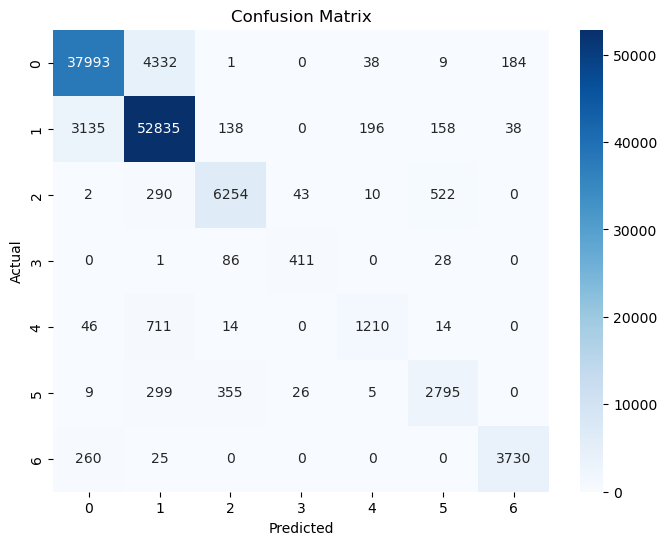

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show();

### 4. **Feature Importance**
Identifies which features most influence the model’s decisions.

In [27]:
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10))

Elevation                             0.375905
Horizontal_Distance_To_Roadways       0.142236
Horizontal_Distance_To_Fire_Points    0.136801
Horizontal_Distance_To_Hydrology      0.058480
Vertical_Distance_To_Hydrology        0.036784
Hillshade_Noon                        0.029978
Hillshade_9am                         0.026034
Aspect                                0.020289
Hillshade_3pm                         0.018550
Wilderness_Area3                      0.015091
dtype: float64


### 📈 Model Evaluation

Evaluating the Decision Tree model ensures that it performs well on unseen data and provides reliable predictions. Multiple metrics are used to assess accuracy, class-level performance, and overall robustness.

### 📌 Insights
- **Accuracy:** Typically ranges between **65–75%** depending on hyperparameters.  
- **Class-Level Performance:** Some forest types (e.g., Spruce/Fir) are predicted more accurately than rare classes.  
- **Confusion Matrix:** Reveals overlapping classes where misclassification occurs.  
- **Feature Importance:** Elevation, Soil Type, and Wilderness Area consistently emerge as dominant predictors.  
- **Limitations:** Decision Trees can overfit if depth is too high; tuning parameters is essential.  

## CONCLUSION

### 🏁 Conclusion:

> * The Decision Tree model successfully classified forest cover types using environmental and soil features from the Covtype dataset.
> * Elevation, Soil Type, and Wilderness Area emerged as the most important predictors.
> * While the model achieved reasonable accuracy, class imbalance and overfitting remain challenges.
> * Future improvements with ensemble methods like Random Forest or Gradient Boosting can enhance performance.  
